# Stress Analysis for a Single Rolling Sphere in Poiseuille Flow
This is designed as an example/tutorial on how to use the `stress_analysis`
module with PARTIES data. The primary purpose of the `stress_analysis`
module is to present a user friendly way to calculate equations 7.12 and 7.14 in
Edward Biegert's 2018 PhD Disertation.

## Contents:
* [Generating Compatible PARTIES Data](#first-bullet)
* [Reading Simulation Data](#second-bullet)
* [The Stress Balance](#third-bullet)

## Generating Compatible PARTIES Data <a class="anchor" id="first-bullet"></a>
Local ibm forcing data is required to calculate stress profiles in a particle
laden flow. Enable the `#POST_PROCESSING` flag in `Boundary.h` to add the ibm
forcing fields to the standard `Data_*.h5` output files.

The `stress_analysis` module reads simulation parameters from the `parties.inp`.
To create accurate stress balances, appropreately define the simulation
parameters there.

An example simulation of a single rolling particle in a poisseuille flow can be
found in `examples/sample_data` directory.

## Reading Simulation Data <a class="anchor" id="first-bullet"></a>
The reading of data is performed by `stress_analysis\data_ingestion.py`.
Simulations are read in as a collection of `.h5` files and an associated
`parties.inp` file. An overview of how to use the `data_ingestion` module is
shown below.

### 1. The Simulation Class
A simulation object is a custom datasturcture that reads and stores simulation
parameters and data from the `parties.inp` and `.h5` files found in the
specified directory.

In [1]:
# Imports for jupyter notebook functionality and plotting
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
sys.path.append(os.path.dirname(os.getcwd()))

# How to craete a Simulation object
from stress_analysis import data_ingestion as data_in

data_directory = os.path.join(os.getcwd(), "sample_data")
sim = data_in.Simulation(data_directory)

The simulation object can be used to access basic simulation parameters.

In [2]:
print(f"The domain length is: {sim.Lx}")
print(f"The number of gridcells in the z direction is: {sim.Nz}")
print(f"The Reynolds number of the simulation is: {sim.Re}")
# print(sim.__dict__)  # List all of the simulation object's attributes

The domain length is: [2.]
The number of gridcells in the z direction is: [48]
The Reynolds number of the simulation is: [1.5]


In addition to the numerical attributes the `Simulation` class also has
`FluidData` and `ParticleData` subclasses which are used to access the
simulation data.

### 2. The FluidData Subclass

The `FluidData` subclass can be accessed via the `Simulation` object. The
`fluid` attribute of the `Simulation` object is an instance of the `FluidData`
class.

In [3]:
print(type(sim.fluid))

<class 'stress_analysis.data_ingestion.FluidData'>


A list of `Data_*.h5` output file indices is stired in the `FluidData.indices`
attribute.

In [4]:
print(f"The `Data_*.h5` file indices in our data directory are: {sim.fluid.indices}")

The `Data_*.h5` file indices in our data directory are: [ 0  1  2  3  4  5  6  7  8  9 10]


The reader functions of the `FluidData` class are used to access data found
in a specified `Data_*.h5` file. A `Data_*.h5` file index is taken as an
argument to the reader functions.

For example the u-velocity and dynamic pressure reader functions are used to
plot the u-velocity and dynamic pressure data from `Data_3.h5` and `Data_7.h5`
below.

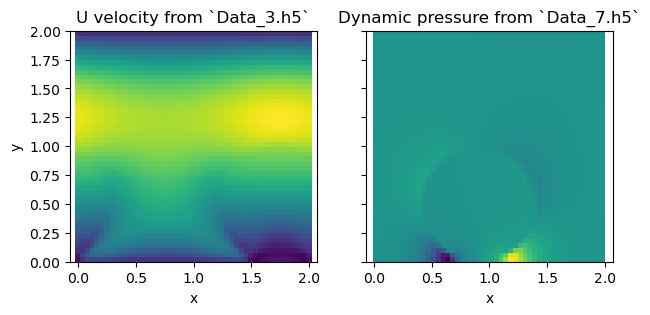

In [5]:
# Choose file indices
idx1 = 3
idx2 = 7

# Access fluid data
u_field = sim.fluid.u(sim.fluid.indices[idx1])
p_field = sim.fluid.p(sim.fluid.indices[idx2])

# Plotting
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(7, 3))

X, Y = np.meshgrid(sim.fluid.xu, sim.fluid.yc)
ax1 = ax[0].pcolor(X, Y, u_field[24, :, :])
ax[0].axis("equal")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].set_title(f"U velocity from `Data_{sim.fluid.indices[idx1]}.h5`")

X, Y = np.meshgrid(sim.fluid.xc, sim.fluid.yc)
ax[1].pcolor(X, Y, p_field[24, :, :])
ax[1].set_xlabel("x")
ax[1].set_title(f"Dynamic pressure from `Data_{sim.fluid.indices[idx2]}.h5`")
ax[1].axis("equal")

plt.show()

### 2. The ParticleData Subclass

The `Simulation.p_mobile` and `Simulation.p_fixed` attributes are instances of
the `ParticleData` subclass. The respective instances are used to read mobile
and fixed particle data from `Particle*.h5` files.

Simliarly to `FluidData` the `ParticleData` class holds the indices of the
`Particle_*.h5` files found in the data directory in the `ParticleData.indices`
attribute.

In [6]:
print(f"The `Particle_*.h5` file indices with mobile particle data in our data directory are: {sim.p_mobile.indices}")
print(f"The `Particle_*.h5` file indices with fixed particle data in our data directory are: {sim.p_fixed.indices}")

The `Particle_*.h5` file indices with mobile particle data in our data directory are: [ 0  1  2  3  4  5  6  7  8  9 10]
The `Particle_*.h5` file indices with fixed particle data in our data directory are: []


Particle count is stored in the `ParticelData.count` attribute.

In [7]:
print(f"There are {sim.p_mobile.count} mobile particles.")
print(f"There are {sim.p_fixed.count} fixed particles")

There are 1 mobile particles.
There are 0 fixed particles


Similarly to the `FluidData` class, the `ParticleData` class's reader functions
can be used to access data from `Particle_*.h5` files.

As an example, the particle x-position and u-velcotiy are accessed and printed
below.

In [8]:
idx = 5
particle_file_idx = sim.p_mobile.indices[5]
particle_position_vector = sim.p_mobile.X(particle_file_idx)
particle_velocity_vector = sim.p_mobile.U(particle_file_idx)

print(f"The particle is at x = {particle_position_vector[0, 0]} and moving with x-velocity u = {particle_velocity_vector[0, 0]}")

The particle is at x = 0.3305835012081337 and moving with x-velocity u = 0.29138763328102113


## The Stress Balances <a class="anchor" id="first-bullet"></a>
The tools to calculate the x and y direction stress balances are found in the
`stress_balance/equations` module.

The x-stress balance (eqn. 7.12 in E. Biegert's dissertation) for a single
rolling particle in a Poisseuille flow is shown below. Similar equations are
available for the y-direction (eqn. 7.14 in E. Biegert's dissertation) and the
particle pressure are also available. See the `stress_balance/equations` module
for more information.

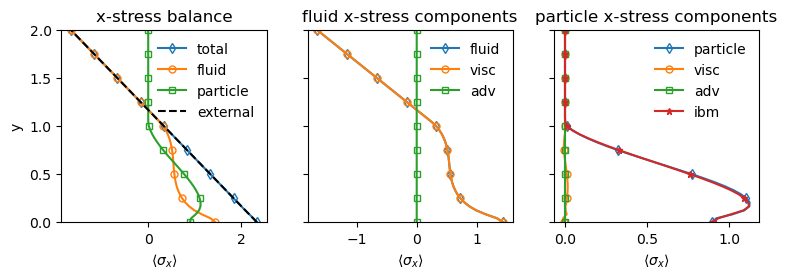

In [9]:
from stress_analysis import equations as eqns

data_file_idx = sim.p_mobile.indices[5]
x_stress = eqns.stress_x(sim, data_file_idx)

fig, ax = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(9, 2.5))

ax[0].plot(x_stress["total"], x_stress["yv"], '-d', markevery=6, markersize=5, markerfacecolor='none')
ax[0].plot(x_stress["fluid"], x_stress["yv"], '-o', markevery=6, markersize=5, markerfacecolor='none')
ax[0].plot(x_stress["particle"], x_stress["yv"], '-s', markevery=6, markersize=5, markerfacecolor='none')
ax[0].plot(x_stress["external"], x_stress["yv"], 'k--')
ax[0].set_xlabel(r"$\langle \sigma_x \rangle$")
ax[0].set_ylabel("y")
ax[0].legend(["total", "fluid", "particle", "external"], frameon=0)
ax[0].set_title("x-stress balance")

ax[1].plot(x_stress["fluid"], x_stress["yv"], '-d', markevery=6, markersize=5, markerfacecolor='none')
ax[1].plot(x_stress["visc_f"], x_stress["yv"], '-o', markevery=6, markersize=5, markerfacecolor='none')
ax[1].plot(x_stress["adv_f"], x_stress["yv"], '-s', markevery=6, markersize=5, markerfacecolor='none')
ax[1].set_xlabel(r"$\langle \sigma_x \rangle$")
ax[1].legend(["fluid", "visc", "adv"], frameon=0)
ax[1].set_title("fluid x-stress components")

ax[2].plot(x_stress["particle"], x_stress["yv"], '-d', markevery=6, markersize=5, markerfacecolor='none')
ax[2].plot(x_stress["visc_p"], x_stress["yv"], '-o', markevery=6, markersize=5, markerfacecolor='none')
ax[2].plot(x_stress["adv_p"], x_stress["yv"], '-s', markevery=6, markersize=5, markerfacecolor='none')
ax[2].plot(x_stress["ibm"], x_stress["yv"], '-*', markevery=6, markersize=5, markerfacecolor='none')
ax[2].set_xlabel(r"$\langle \sigma_x \rangle$")
ax[2].legend(["particle", "visc", "adv", "ibm"], frameon=0)
ax[2].set_title("particle x-stress components")

plt.ylim([0, 2])
plt.show()
